In [10]:
import pandas as pd
import random
import re

# read the data
data = pd.read_csv("../../data/answerList_data.csv")
print(data.head())


   Answer.ID FailingMethod  Question.ID  Answer.duration  Answer.confidence  \
0        261       HIT01_8            0           90.984                  4   
1        262       HIT01_8            0          133.711                  5   
2        263       HIT01_8            0           77.696                  5   
3        264       HIT01_8            0           46.644                  1   
4        265       HIT01_8            0          215.416                  5   

   Answer.difficulty  Ground_Truth  TP  TN  FN  ...  Code.complexity  \
0                  2             0   0   1   0  ...                1   
1                  1             0   0   1   0  ...                1   
2                  2             0   0   1   0  ...                1   
3                  1             0   0   1   0  ...                1   
4                  5             0   0   1   0  ...                1   

                        Worker.ID  Worker.score       Worker.profession  \
0   832cg-7G1i-46

In [11]:
# Calculate Type-Token Ratio (TTR)
def calculate_ttr(text):
    # Tokenize the text by splitting on non-alphabetic characters and converting to lowercase
    text = str(text)
    tokens = re.findall(r'\b\w+\b', text.lower())  # Tokenize and ignore case
    types = set(tokens)  # Unique words
    num_tokens = len(tokens)
    num_types = len(types)
    
    # Calculate TTR
    return num_types / num_tokens if num_tokens > 0 else 0

# Apply the function to the 'Answer.explanation' column
data['TTR'] = data['Answer.explanation'].apply(calculate_ttr)

print(data['TTR'].head())
print(data['Answer.explanation'].head())

0    0.875000
1    0.846154
2    0.733333
3    0.909091
4    0.882353
Name: TTR, dtype: float64
0    hoursOffset accepts negative numbers between -...
1    the conditional clause is correct for the give...
2    The argument -2 is within the range (-23;23); ...
3    The exception is in no way related to the hour...
4    The issue cannot be with hoursOffset since the...
Name: Answer.explanation, dtype: object


In [12]:
# prepare the relevant columns

# Worker profession is a string, convert to a number
data["Worker.profession"] = data["Worker.profession"].astype('category').cat.codes

# participant score and profession, duration, explanation size/complexity, confidence and difficulty
relevant_columns=["Worker.score", "Worker.profession", "Answer.duration", "TTR", "Answer.confidence", 
                  "Answer.difficulty", "Ground_Truth", "FailingMethod", "Answer.explanation"]

# discard the rest
data = data[relevant_columns]

In [13]:
# Ensure reproducibility
random.seed(42)

# Get bug reports
failing_methods = data['FailingMethod'].unique()

# Create holdout and training set
number_of_holdout_bug_reports = 2
selected_failing_methods = random.sample(list(failing_methods), number_of_holdout_bug_reports)
holdout_set = data[data['FailingMethod'].isin(selected_failing_methods)]
training_set = data[~data['FailingMethod'].isin(selected_failing_methods)]



In [14]:
print(training_set['FailingMethod'].unique())
print(holdout_set['FailingMethod'].unique())

['HIT03_6' 'HIT04_7' 'HIT05_35' 'HIT06_51' 'HIT07_33' 'HIT08_54']
['HIT01_8' 'HIT02_24']


In [15]:
# train a decision tree based approach e.g. random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.metrics import precision_score, recall_score, classification_report, accuracy_score

# Use Ground_Truth as the target
X = training_set.drop(columns=["Ground_Truth", "FailingMethod", "Answer.explanation"])
y = training_set["Ground_Truth"]

# Split the data into training and validation sets for cross-validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(random_state=42, n_estimators=100)

cv_predictions = cross_val_predict(rf_classifier, X, y, cv=5) # cross validation

# Calculate precision and recall
cv_precision = precision_score(y, cv_predictions, average='binary')
cv_recall = recall_score(y, cv_predictions, average='binary')

print("Cross-Validation Precision:", cv_precision)
print("Cross-Validation Recall:", cv_recall)

# Calculate precision and recall per bug report 
bug_report_metrics = {}
for bug_report in training_set["FailingMethod"].unique():
    mask = training_set["FailingMethod"] == bug_report
    # Filter both y and cv_predictions for the specific bug report
    report_precision = precision_score(y[mask], cv_predictions[mask], average='binary')
    report_recall = recall_score(y[mask], cv_predictions[mask], average='binary')
    bug_report_metrics[bug_report] = {"precision": report_precision, "recall": report_recall}

print("\nCross-Validation Metrics per Bug Report:")
for bug_report, metrics in bug_report_metrics.items():
    print(f"{bug_report}: Precision={metrics['precision']:.2f}, Recall={metrics['recall']:.2f}")

# Train the model on the training set
rf_classifier.fit(X_train, y_train)

Cross-Validation Precision: 0.22857142857142856
Cross-Validation Recall: 0.0380952380952381

Cross-Validation Metrics per Bug Report:
HIT03_6: Precision=0.44, Recall=0.09
HIT04_7: Precision=0.08, Recall=0.02
HIT05_35: Precision=0.25, Recall=0.03
HIT06_51: Precision=0.11, Recall=0.02
HIT07_33: Precision=0.60, Recall=0.05
HIT08_54: Precision=0.14, Recall=0.02


RandomForestClassifier(random_state=42)

In [16]:
print(holdout_set["Ground_Truth"].isnull().sum())

# find out where the Nan values are
print(holdout_set[holdout_set["Ground_Truth"].isnull()])

0
Empty DataFrame
Columns: [Worker.score, Worker.profession, Answer.duration, TTR, Answer.confidence, Answer.difficulty, Ground_Truth, FailingMethod, Answer.explanation]
Index: []


In [17]:
# predict on the holdout set
X_holdout = holdout_set.drop(columns=["Ground_Truth", "FailingMethod", "Answer.explanation"])
y_holdout = holdout_set["Ground_Truth"]
holdout_predictions = rf_classifier.predict(X_holdout)
# Calculate precision and recall on the holdout set
holdout_precision = precision_score(y_holdout, holdout_predictions, average='binary')
holdout_recall = recall_score(y_holdout, holdout_predictions, average='binary')
print("\nHoldout Precision:", holdout_precision)
print("Holdout Recall:", holdout_recall)
# Calculate holdout set metrics per bug report
holdout_bug_report_metrics = {}
for bug_report in holdout_set["FailingMethod"].unique():
    mask = holdout_set["FailingMethod"] == bug_report
    report_precision = precision_score(y_holdout[mask], holdout_predictions[mask], average='binary')
    report_recall = recall_score(y_holdout[mask], holdout_predictions[mask], average='binary')
    holdout_bug_report_metrics[bug_report] = {"precision": report_precision, "recall": report_recall}
print("\nHoldout Set Metrics per Bug Report:")
for bug_report, metrics in holdout_bug_report_metrics.items():
    print(f"{bug_report}: Precision={metrics['precision']:.2f}, Recall={metrics['recall']:.2f}")


Holdout Precision: 0.3333333333333333
Holdout Recall: 0.025

Holdout Set Metrics per Bug Report:
HIT01_8: Precision=0.25, Recall=0.03
HIT02_24: Precision=0.50, Recall=0.03


c:\Users\bzwad\anaconda3\envs\DSWebscrape\lib\site-packages\seaborn\distributions.py:254: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  baselines.iloc[:, cols] = (curves
c:\Users\bzwad\anaconda3\envs\DSWebscrape\lib\site-packages\seaborn\distributions.py:254: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  baselines.iloc[:, cols] = (curves
c:\Users\bzwad\anaconda3\envs\DSWebscrape\lib\site-packages\seaborn\distributions.py:254: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting

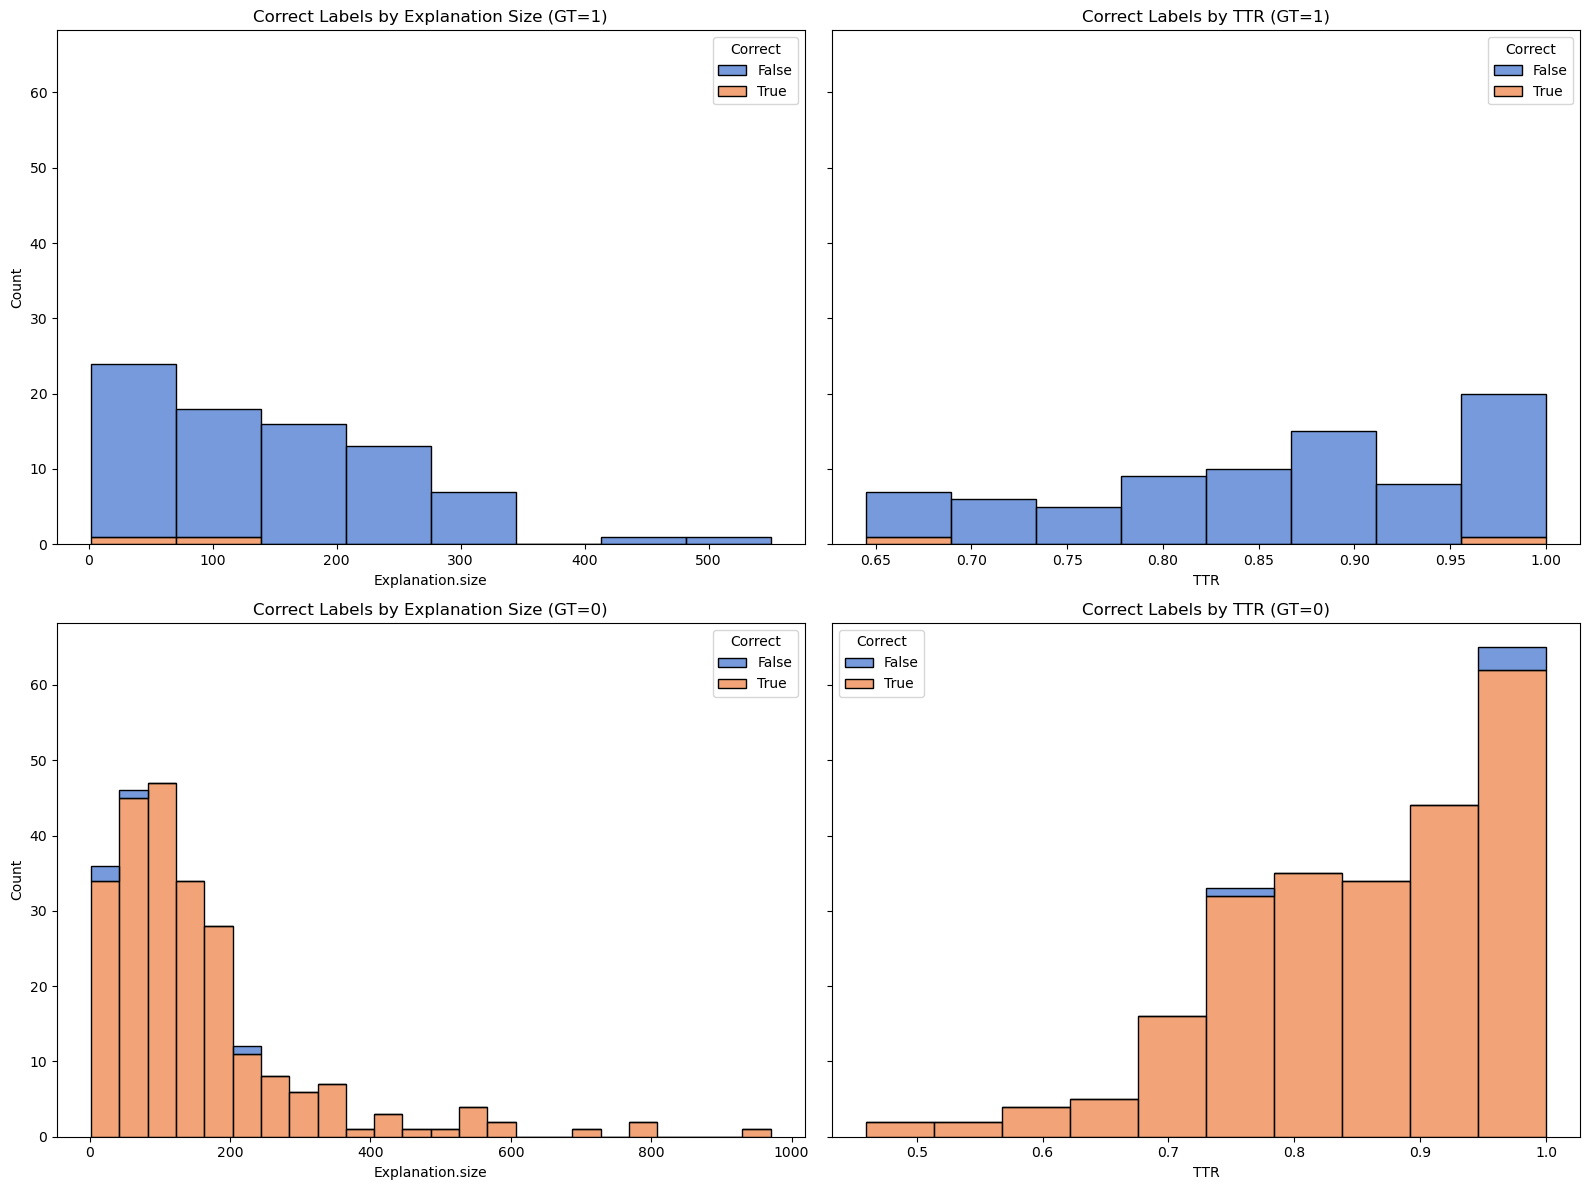

In [19]:
# For the inspection tasks (rows) that host the bug, show the distribution of correct labels by
# explanation size and complexity

# meaning: take all rows with ground truth == 1 and ground truth == 0 respectively
# show the distribution of correct labels by explanation size and complexity(TTR)
# correct labels are when the Ground truth == the prediction

import matplotlib.pyplot as plt
import seaborn as sns


# Add a column indicating whether the prediction is correct
holdout_set = holdout_set.copy()  # Avoid SettingWithCopyWarning
holdout_set.loc[:, 'Correct'] = holdout_set['Ground_Truth'] == holdout_predictions

# Ensure 'Explanation.size' exists
holdout_set['Explanation.size'] = holdout_set['Answer.explanation'].apply(lambda x: len(str(x)))

# Filter data for Ground_Truth == 1 and Ground_Truth == 0
ground_truth_1 = holdout_set[holdout_set['Ground_Truth'] == 1].copy()
ground_truth_0 = holdout_set[holdout_set['Ground_Truth'] == 0].copy()

# Plot distribution function
def plot_distribution(data, feature, title, ax):
    sns.histplot(data=data, x=feature, hue='Correct', multiple='stack', kde=False, palette='muted', ax=ax)
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

# Set up the plotting grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)

# Plot for Explanation.size and TTR for Ground_Truth == 1
plot_distribution(ground_truth_1, 'Explanation.size', 'Correct Labels by Explanation Size (GT=1)', axes[0, 0])
plot_distribution(ground_truth_1, 'TTR', 'Correct Labels by TTR (GT=1)', axes[0, 1])

# Plot for Explanation.size and TTR for Ground_Truth == 0
plot_distribution(ground_truth_0, 'Explanation.size', 'Correct Labels by Explanation Size (GT=0)', axes[1, 0])
plot_distribution(ground_truth_0, 'TTR', 'Correct Labels by TTR (GT=0)', axes[1, 1])

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


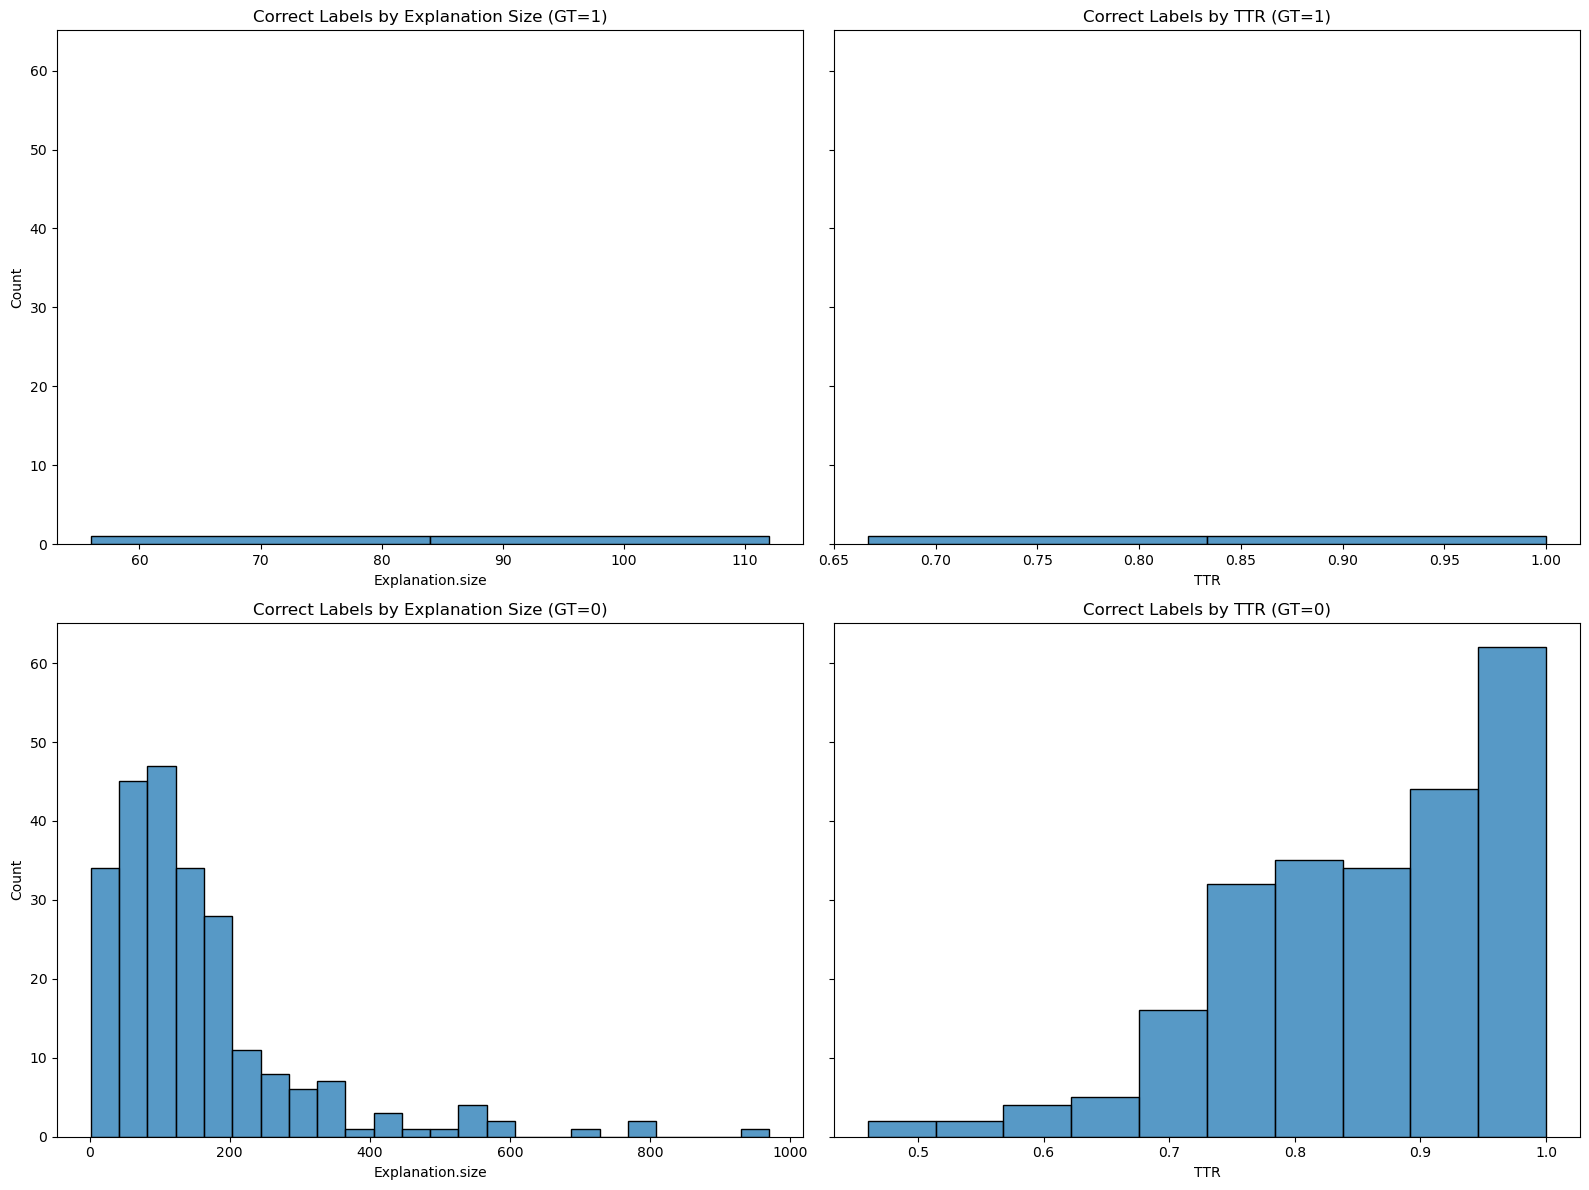

In [20]:
# Filter only correct predictions
ground_truth_1_correct = ground_truth_1[ground_truth_1['Correct'] == True]
ground_truth_0_correct = ground_truth_0[ground_truth_0['Correct'] == True]

# Create a function to plot distributions for correct labels only
def plot_correct_distribution(data, feature, title, ax):
    sns.histplot(data=data, x=feature, kde=False, palette='muted', ax=ax)
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

# Set up the plotting grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)

# Plot for Explanation.size and TTR for Ground_Truth == 1
plot_correct_distribution(ground_truth_1_correct, 'Explanation.size', 'Correct Labels by Explanation Size (GT=1)', axes[0, 0])
plot_correct_distribution(ground_truth_1_correct, 'TTR', 'Correct Labels by TTR (GT=1)', axes[0, 1])

# Plot for Explanation.size and TTR for Ground_Truth == 0
plot_correct_distribution(ground_truth_0_correct, 'Explanation.size', 'Correct Labels by Explanation Size (GT=0)', axes[1, 0])
plot_correct_distribution(ground_truth_0_correct, 'TTR', 'Correct Labels by TTR (GT=0)', axes[1, 1])

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


In [22]:
# Only keep the rows with correct answers (assumption: given by users) 
# so Ground Truth == 1 and Answer YES, Ground Truth == 0 and Answer NO

correct_answers = holdout_set[(holdout_set['Ground_Truth'] == 1) & (holdout_set['Correct'] == True) | 
                               (holdout_set['Ground_Truth'] == 0) & (holdout_set['Correct'] == True)]

# only keep columns Ground_Truth,FailingMethod,Answer.explanation

correct_answers = correct_answers[["Ground_Truth", "FailingMethod", "Answer.explanation"]]

# Save the correct answers to a CSV file
correct_answers.to_csv("correct_answers.csv", index=False)